In [ ]:
!pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kausthubkannan/5-flower-types-classification-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the '5-flower-types-classification-dataset' dataset.
Path to dataset files: /kaggle/input/5-flower-types-classification-dataset


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
Train_Datagen=ImageDataGenerator(rescale=1./255,validation_split=0.2)

In [ ]:
import os
Training_Generator=Train_Datagen.flow_from_directory(os.path.join(path, "flower_images"),
                                                     target_size=(224,224),
                                                     batch_size=32,
                                                     class_mode='categorical',
                                                     subset="training",

                                                     )

Found 4000 images belonging to 5 classes.


In [ ]:
Validation_Generator=Train_Datagen.flow_from_directory(os.path.join(path, "flower_images"),
                                                     target_size=(224,224),
                                                     batch_size=32,
                                                     class_mode='categorical',
                                                     subset="validation",

                                                     )

Found 1000 images belonging to 5 classes.


In [ ]:
class_indices=Training_Generator.class_indices
keys=list(class_indices.keys())
print(keys)


['Lilly', 'Lotus', 'Orchid', 'Sunflower', 'Tulip']


In [ ]:
model=keras.Sequential([
    layers.Conv2D(32,(3,3),activation="relu",input_shape=(224,224,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(5,activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model.fit(Training_Generator,validation_data=Validation_Generator,epochs=6)

Epoch 1/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 294ms/step - accuracy: 0.4757 - loss: 1.3138 - val_accuracy: 0.5750 - val_loss: 1.0287
Epoch 2/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 157ms/step - accuracy: 0.6768 - loss: 0.8629 - val_accuracy: 0.7070 - val_loss: 0.7642
Epoch 3/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 148ms/step - accuracy: 0.8167 - loss: 0.5142 - val_accuracy: 0.7690 - val_loss: 0.6852
Epoch 4/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 148ms/step - accuracy: 0.9095 - loss: 0.2784 - val_accuracy: 0.8180 - val_loss: 0.6834
Epoch 5/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 154ms/step - accuracy: 0.9663 - loss: 0.1146 - val_accuracy: 0.8390 - val_loss: 0.8322
Epoch 6/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 146ms/step - accuracy: 0.9875 - loss: 0.0599 - val_accuracy: 0.8420 - val_loss: 0.8528


In [ ]:
model.save('/content/drive/MyDrive/FLower_detection.h5')

In [ ]:
from tensorflow.keras.models import load_model
model=load_model("FLower_detection.h5")
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

In [ ]:
test_image_path="/content/drive/MyDrive/lily.jpg"

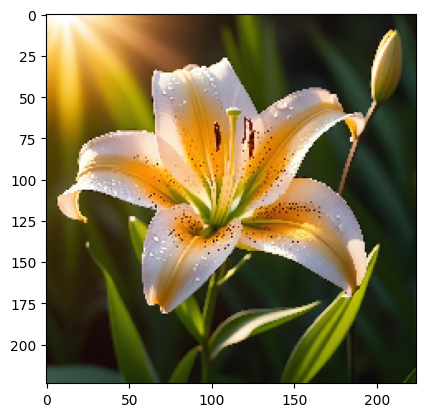

In [ ]:
img = image.load_img(test_image_path, target_size=(224, 224))
plt.imshow(img)
plt.axis()
plt.show()

In [ ]:
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 815ms/step
[[8.2019019e-01 6.7546412e-06 3.6436417e-03 1.7615719e-01 2.2881193e-06]]


In [ ]:
prediction = model.predict(img_array)
index=np.argmax(prediction[0])
print(keys[index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Lilly
